In [2]:
# instalamos el paquete para descargar archivos wget
#!pip install wget

# importamos wget y las librerías que nos faltan
from wget import download
from os import path
import pandas as pd

# descargamos la base de datos
if not path.exists("movies.csv"):
  download("https://ignaciorlando.github.io/datasets/data-science/movies.csv")
else:
  print("No vamos a bajar el archivo de movies porque ya existe!")

No vamos a bajar el archivo de movies porque ya existe!


In [22]:
#df = pd.read_csv("movies.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   MOVIES             9999 non-null   str    
 1   YEAR               9355 non-null   str    
 2   GENRE              9919 non-null   str    
 3   RATING             8179 non-null   float64
 4   ONE-LINE           9999 non-null   str    
 5   STARS              9999 non-null   str    
 6   VOTES              8179 non-null   str    
 7   RunTime            7041 non-null   float64
 8   Gross              460 non-null    str    
 9   genre_Action       9999 non-null   int64  
 10  genre_Adventure    9999 non-null   int64  
 11  genre_Animation    9999 non-null   int64  
 12  genre_Comedy       9999 non-null   int64  
 13  genre_Crime        9999 non-null   int64  
 14  genre_Documentary  9999 non-null   int64  
 15  genre_Drama        9999 non-null   int64  
 16  genre_Other        9999 non-null   

In [4]:
# Reemplazamos el '\n' por un texto vacío y luego usamos strip() para borrar espacios extra
df['GENRE'] = df['GENRE'].str.replace('\n', '').str.strip()
df['STARS'] = df['STARS'].str.replace('\n', '').str.strip()
df['ONE-LINE'] = df['ONE-LINE'].str.replace('\n', '').str.strip()

df.head(10)

,MOVIES,YEAR,GENRE,RATING,ONE-LINE,STARS,VOTES,RunTime,Gross
0,Blood Red Sky,(2021),"Action, Horror, Thriller",6.1,A woman with a mysterious illness is forced in...,Director:Peter Thorwarth| Stars:Peri Baume...,"21,062",121.0,NaN
1,Masters of the Universe: Revelation,(2021– ),"Animation, Action, Adventure",5.0,The war for Eternia begins again in what may b...,"Stars:Chris Wood, Sarah Michelle Gellar, Lena ...","17,870",25.0,NaN
2,The Walking Dead,(2010–2022),"Drama, Horror, Thriller",8.2,Sheriff Deputy Rick Grimes wakes up from a com...,"Stars:Andrew Lincoln, Norman Reedus, Melissa M...","885,805",44.0,NaN
3,Rick and Morty,(2013– ),"Animation, Adventure, Comedy",9.2,An animated series that follows the exploits o...,"Stars:Justin Roiland, Chris Parnell, Spencer G...","414,849",23.0,NaN
4,Army of Thieves,(2021),"Action, Crime, Horror",NaN,"A prequel, set before the events of Army of th...",Director:Matthias Schweighöfer| Stars:Matt...,NaN,NaN,NaN
5,Outer Banks,(2020– ),"Action, Crime, Drama",7.6,A group of teenagers from the wrong side of th...,"Stars:Chase Stokes, Madelyn Cline, Madison Bai...","25,858",50.0,NaN
6,The Last Letter from Your Lover,(2021),"Drama, Romance",6.8,A pair of interwoven stories set in the past a...,Director:Augustine Frizzell| Stars:Shailen...,"5,283",110.0,NaN
7,Dexter,(2006–2013),"Crime, Drama, Mystery",8.6,"By day, mild-mannered Dexter is a blood-spatte...","Stars:Michael C. Hall, Jennifer Carpenter, Dav...","665,387",53.0,NaN
8,Never Have I Ever,(2020– ),Comedy,7.9,The complicated life of a modern-day first gen...,"Stars:Maitreyi Ramakrishnan, Poorna Jagannatha...","34,530",30.0,NaN
9,Virgin River,(2019– ),"Drama, Romance",7.4,"Seeking a fresh start, nurse practitioner Meli...","Stars:Alexandra Breckenridge, Martin Henderson...","27,279",44.0,NaN


In [5]:
# Asumiendo que ya limpiaste los saltos de línea (\n) como vimos antes
# Generamos las dummies separando por la coma y el espacio
dummy_genres = df['GENRE'].str.get_dummies(sep=', ')

# Le agregamos un prefijo para mantener el orden
dummy_genres = dummy_genres.add_prefix('genre_')
print(f"Number of genre columns: {len(dummy_genres.columns)}")

# Sumamos cada columna (los 1s) para obtener el total por género
genre_counts = dummy_genres.sum().sort_values(ascending=False)

# Concatenamos las variables dummy al dataset original usando axis=1 (columnas)
#df = pd.concat([df, dummy_genres], axis=1)

#df.info()

Number of genre columns: 27


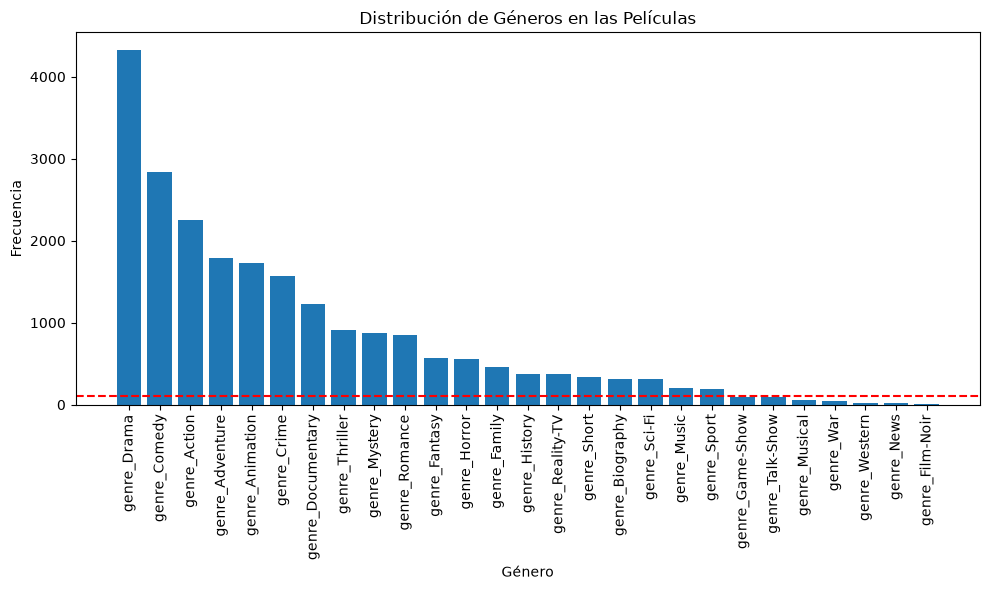

In [6]:
# Mostramos el resultado
#print(genre_counts)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=90) 
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.title('Distribución de Géneros en las Películas')

# Agrega una línea roja en el umbral que consideres (ej. 100 películas)
plt.axhline(y=100, color='red', linestyle='--') 

plt.tight_layout() 
plt.show()

Para tratar los generos, vamos a crear dummy values. Todos los generos que tengan menos de 1000 columnas caen en "otros"

In [7]:
# Asumiendo que ya limpiaste los saltos de línea (\n) como vimos antes
# Generamos las dummies separando por la coma y el espacio
dummy_genres = df['GENRE'].str.get_dummies(sep=', ')

# Le agregamos un prefijo para mantener el orden
dummy_genres = dummy_genres.add_prefix('genre_')
print(f"Number of genre columns: {len(dummy_genres.columns)}")

# Sumamos cada columna (los 1s) para obtener el total por género
genre_counts = dummy_genres.sum().sort_values(ascending=False)
# 1. Identificamos los géneros raros (por debajo de tu umbral, por ejemplo 100)
limit = 1000
rare_genres = genre_counts[genre_counts < limit].index

# Creamos la columna 'genre_Other' dentro del DataFrame de dummies.
# Si la suma de los géneros raros en una fila es mayor a 0, le asignamos 1, sino 0.
dummy_genres['genre_Other'] = (dummy_genres[rare_genres].sum(axis=1) > 0).astype(int)

# Eliminamos las columnas individuales de esos géneros raros para mantener solo los principales y el "Other"
dummy_genres = dummy_genres.drop(columns=rare_genres)

# Concatenamos las variables dummy agrupadas al dataset original
df = pd.concat([df, dummy_genres], axis=1)


Number of genre columns: 27


In [8]:

#for idx, val in df["YEAR"].value_counts().items():
# print(idx, val)
df.isna().sum()

MOVIES                  0
YEAR                  644
GENRE                  80
RATING               1820
ONE-LINE                0
STARS                   0
VOTES                1820
RunTime              2958
Gross                9539
genre_Action            0
genre_Adventure         0
genre_Animation         0
genre_Comedy            0
genre_Crime             0
genre_Documentary       0
genre_Drama             0
genre_Other             0
dtype: int64

Acomodemos los anos. Vamos a tomar el primero solamente

In [25]:
import pandas as pd

# 1. Usamos apply y lambda para reemplazar la coma solo en los valores que no son nulos
df['VOTES'] = df['VOTES'].apply(lambda x: str(x).replace(',', '') if pd.notnull(x) else x)

# 2. Ahora sí, forzamos el tipo a número entero tolerante a NaNs
df['VOTES'] = df['VOTES'].astype('Int64')

# Verificamos
print(df['VOTES'].head())

ValueError: invalid literal for int() with base 10: '21062.0'

In [24]:
# Reemplazamos las comas por texto vacío y convertimos a número entero (tolerando NaNs)
df['VOTES'] = df['VOTES'].str.replace(',', '').astype('Int64')

# Verificamos los cambios viendo la información de las columnas
print(df['VOTES'].head())
# calculamos las correlaciones entre features e imprimimos la matriz
correlation_matrix = movies_clean[['start_year', 'RunTime', 'RATING', 'VOTES']].corr()
print(correlation_matrix)

AttributeError: Can only use .str accessor with string values, not integer

Ahora las hipotesis. Primero la de la duracion que aumenta en funcion del ano.

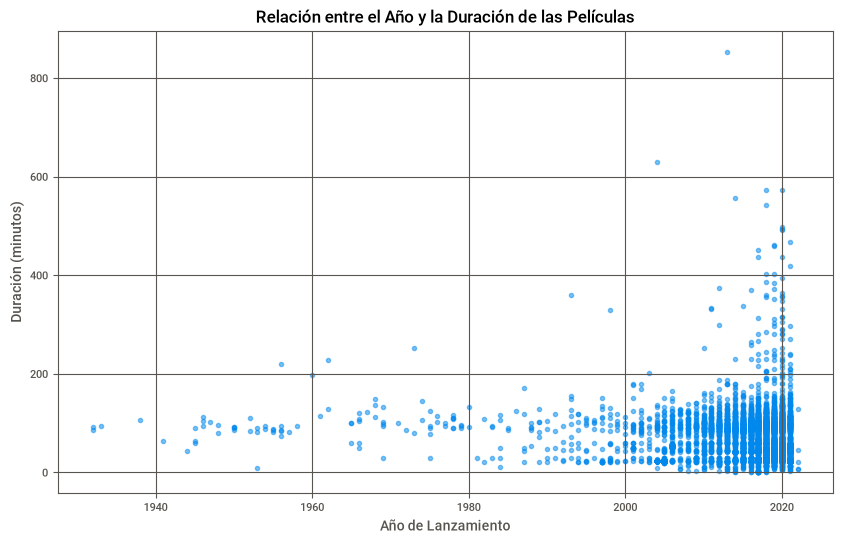

In [18]:
# 4. Definimos las variables para el gráfico
variable_x = 'start_year'
variable_y = 'RunTime'

# 5. Creamos el scatter plot tal como en la Unidad 3
plt.figure(figsize=(10, 6))
plt.scatter(df[variable_x], df[variable_y], alpha=0.5)

# Añadimos etiquetas y título
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Duración (minutos)')
plt.title('Relación entre el Año y la Duración de las Películas')
plt.grid(True)
plt.show()

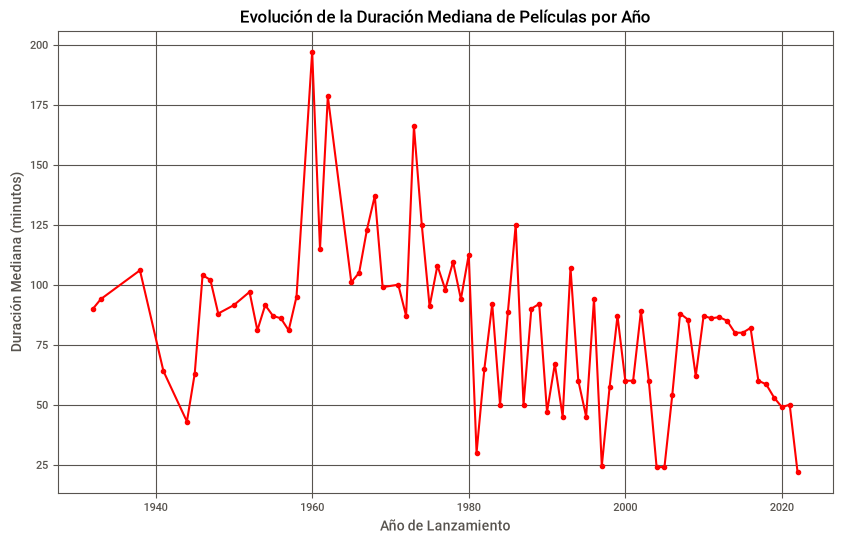

In [19]:
# Agrupamos por año y calculamos la duración mediana
yearly_runtime = df.groupby('start_year')['RunTime'].median()

# Graficamos la tendencia de la mediana
plt.figure(figsize=(10, 6))
plt.plot(yearly_runtime.index, yearly_runtime.values, marker='o', linestyle='-', color='red')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Duración Mediana (minutos)')
plt.title('Evolución de la Duración Mediana de Películas por Año')
plt.grid(True)
plt.show()

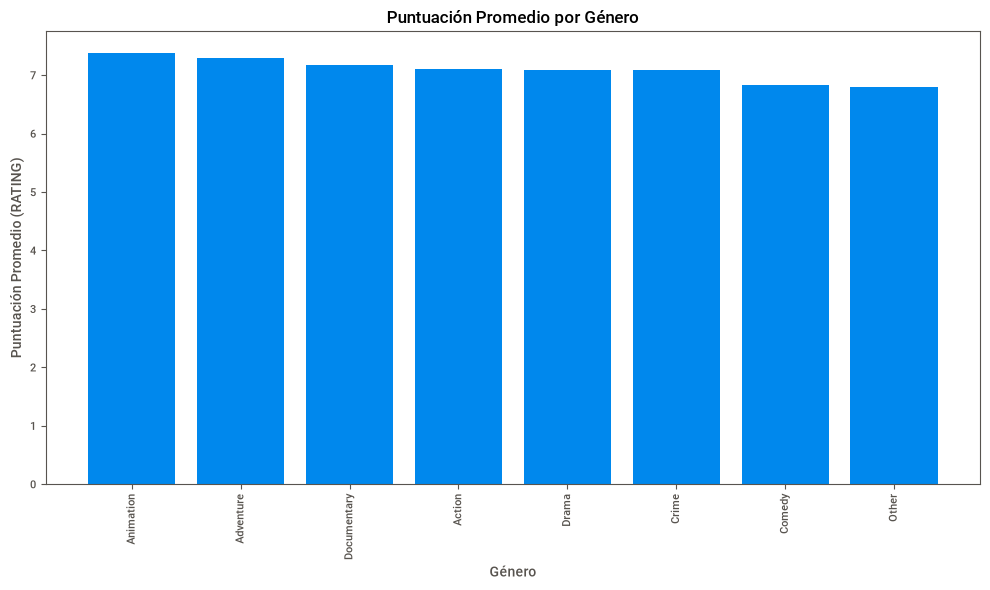

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identificamos todas las columnas que corresponden a géneros (las que empiezan con 'genre_')
columnas_generos = [col for col in df.columns if col.startswith('genre_')]

# 2. Calculamos el RATING promedio para cada género
promedios_rating = {}
for col in columnas_generos:
    # Filtramos las filas que pertenecen a este género (donde la dummy es 1) y calculamos la media del RATING
    promedio = df[df[col] == 1]['RATING'].mean()
    
    # Le sacamos el prefijo 'genre_' al nombre para que las etiquetas del gráfico queden más limpias
    nombre_limpio = col.replace('genre_', '')
    promedios_rating[nombre_limpio] = promedio

# Convertimos nuestro diccionario a una Serie de Pandas y lo ordenamos de mayor a menor puntuación
ratings_por_genero = pd.Series(promedios_rating).sort_values(ascending=False)

# 3. Armamos el gráfico de barras respetando el estilo de tu cuaderno
plt.figure(figsize=(10, 6)) # Ajusta el tamaño de la figura[cite: 2]

# Creamos el gráfico de barras pasando los géneros al eje x y los promedios al eje y
plt.bar(ratings_por_genero.index, ratings_por_genero.values)

plt.xticks(rotation=90) # Rota las etiquetas del eje x para mayor legibilidad[cite: 2]
plt.xlabel('Género')
plt.ylabel('Puntuación Promedio (RATING)')
plt.title('Puntuación Promedio por Género')

plt.tight_layout() # Ajusta el diseño para evitar superposiciones[cite: 2]
plt.show()